# 🎟️ Support Ticket Classification & Prioritization

### Machine Learning Project
### Name: Your Name
### Dataset: Support Tickets

In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from wordcloud import WordCloud

sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (10,6)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 📂 Load Dataset

In [3]:
df = pd.read_csv('all_tickets_processed_improved_v3.csv')
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


## 🔍 Data Overview

In [5]:
df.info()
df['Topic_group'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

## 🧹 Text Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Document'].apply(clean_text)
df.head()

,Document,Topic_group,clean_text
0,connection with icon icon dear please setup ic...,Hardware,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,Access,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,Hardware,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,Access,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,Miscellaneous,mail verification warning hi got attached plea...


## 📊 Data Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_9656\1267094775.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Topic_group', data=df, palette='viridis')


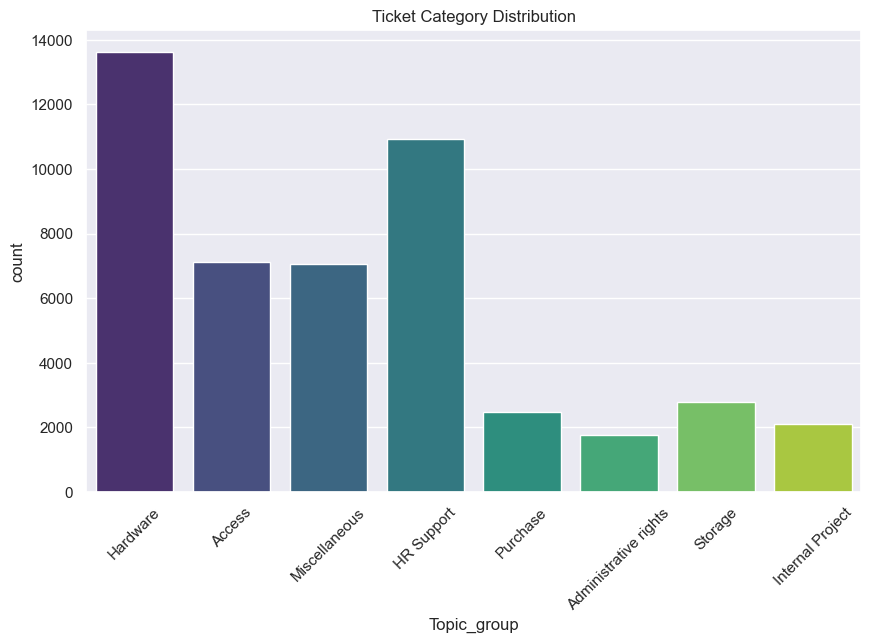

In [7]:
sns.countplot(x='Topic_group', data=df, palette='viridis')
plt.title("Ticket Category Distribution")
plt.xticks(rotation=45)
plt.show()

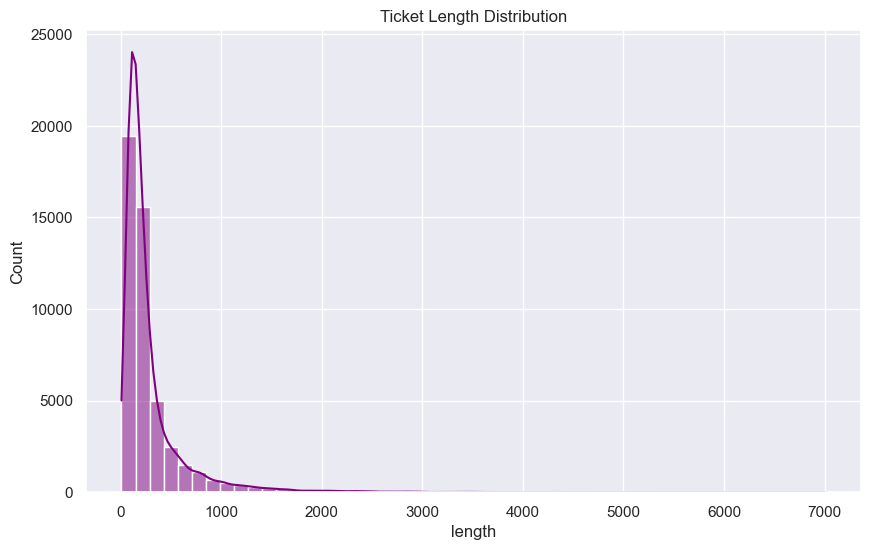

In [8]:
df['length'] = df['Document'].apply(len)

sns.histplot(df['length'], bins=50, kde=True, color='purple')
plt.title("Ticket Length Distribution")
plt.show()

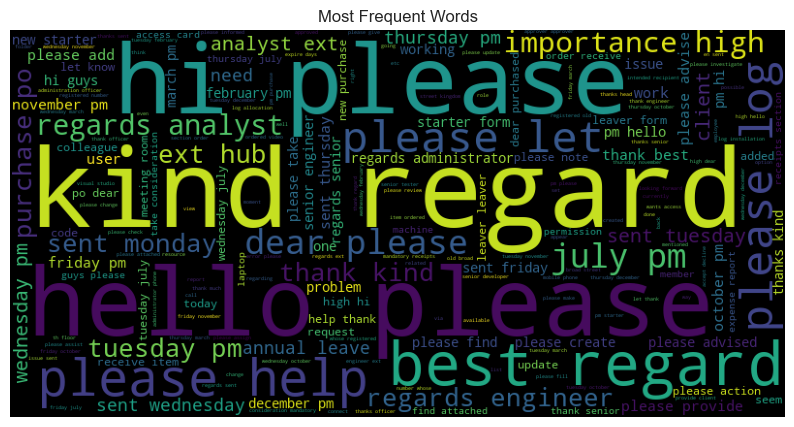

In [9]:
text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Frequent Words")
plt.show()

## 🔢 Feature Extraction (TF-IDF)

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['Topic_group']

## 🤖 Model Training

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

## 📈 Model Evaluation

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

acc = accuracy_score(y_test, y_pred)

plt.bar(["Accuracy"], [acc])
plt.title("Model Accuracy")
plt.show()

probs = model.predict_proba(X_test)
confidence = probs.max(axis=1)

plt.hist(confidence, bins=30, color='green')
plt.title("Prediction Confidence")
plt.show()

## ⚡ Priority Prediction

In [12]:
def assign_priority(text):
    text = text.lower()
    
    if any(word in text for word in ["urgent", "asap", "not working", "down"]):
        return "High"
    elif any(word in text for word in ["slow", "delay", "issue"]):
        return "Medium"
    else:
        return "Low"

df['priority'] = df['Document'].apply(assign_priority)

## 📈 Model Evaluation

In [13]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.68      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.92      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



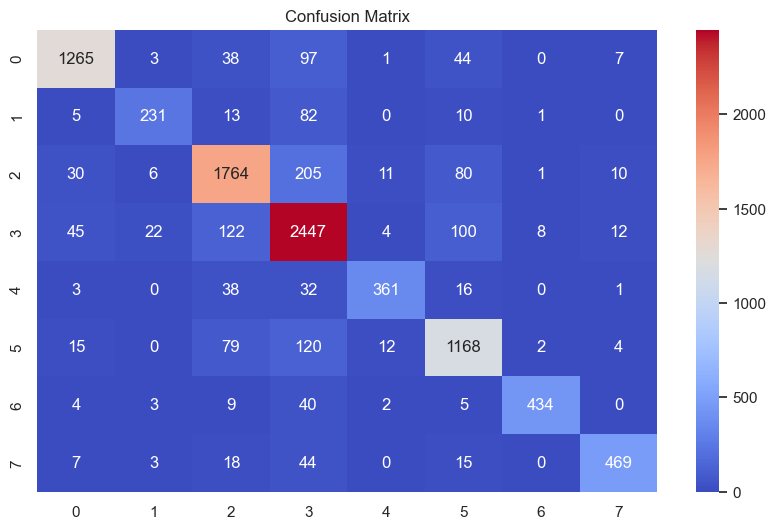

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

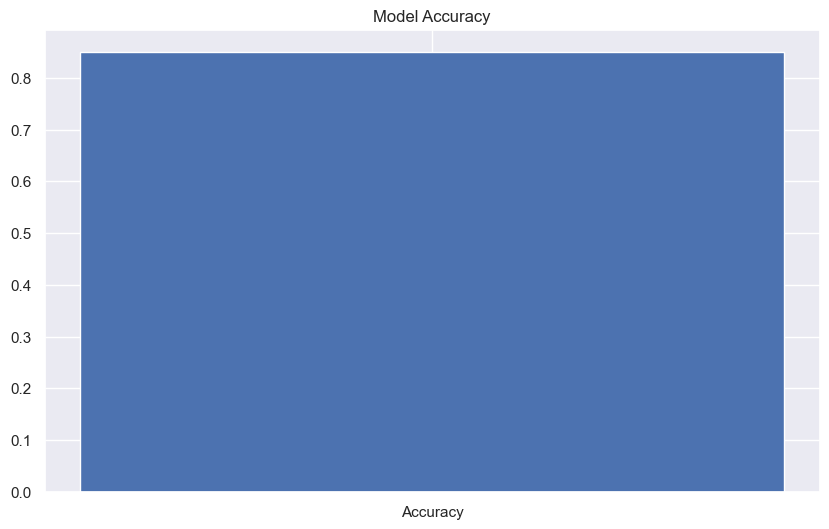

In [15]:
acc = accuracy_score(y_test, y_pred)

plt.bar(["Accuracy"], [acc])
plt.title("Model Accuracy")
plt.show()

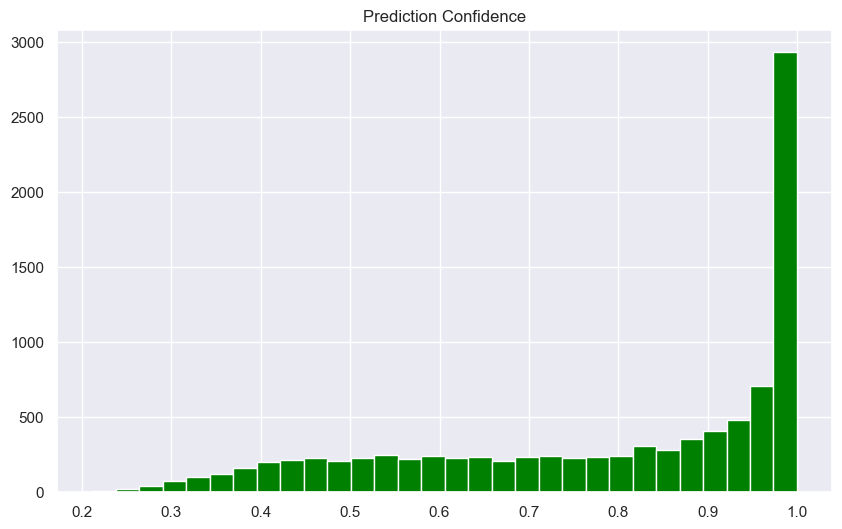

In [16]:
probs = model.predict_proba(X_test)
confidence = probs.max(axis=1)

plt.hist(confidence, bins=30, color='green')
plt.title("Prediction Confidence")
plt.show()

## ⚡ Priority Prediction

In [17]:
def assign_priority(text):
    text = text.lower()
    
    if any(word in text for word in ["urgent", "asap", "not working", "down"]):
        return "High"
    elif any(word in text for word in ["slow", "delay", "issue"]):
        return "Medium"
    else:
        return "Low"

df['priority'] = df['Document'].apply(assign_priority)